In [2]:
from objects import generate_wh_automorphism, word, elem, Elem, getFreeGroup, make_whitehead_graph, draw_whitehead_graph 
from graph_tool.all import min_cut, graph_draw, Graph

/nix/store/gdyl89d3lgffvxb3qjqlh91m12x8lifr-python3-3.13.12-env/lib/python3.13/site-packages/graph_tool/draw/cairo_draw.py:1553: RuntimeWarning: Error importing Gtk module: ; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


In [2]:
fg = getFreeGroup(4)
A = {elem("c"), elem("a")}
x = elem("d")
mp = generate_wh_automorphism(x, A, fg)
print(mp.map(word("b d c d^-1")))

bc


In [7]:
fg = getFreeGroup(4)
A = {elem("a"), elem("c")}
x = elem("c")
mp = generate_wh_automorphism(x, A, fg)
print(mp.morphism_map)
w = word("d^-1 b^-1 a^3 c^-1 b^-3 a^1 b^-2")
mw = mp.map(w)
print(w.length, mw.length)

{'a': ac, 'b': b, 'c': c, 'd': d}
12 14


In [30]:
mp.map(w).length

24

In [17]:
fg = getFreeGroup(3)
w = word("c^-1 b^-1 c^1 a^-2 c^-3 a^1 c^-2 b^1 c^-2 a^3 c^-3 b^2")
g = make_whitehead_graph(w)
p1, p2 = create_partitions(g)
print(p1, p2)
min_word = w
elem = None
for part in [p1, p2]:
    for elem in part:
        if elem.inv() not in part:
            print(elem)
            phi = generate_wh_automorphism(elem, part, fg)
            print(phi.morphism_map)
            print(phi.map(w))
            if phi.map(w).length < min_word.length:
                min_word = phi.map(w)
print("min: ", min_word, min_word.length)

{b} {b⁻¹, c, a⁻¹, a, c⁻¹}
b
{'a': a, 'b': b, 'c': c}
c⁻¹b⁻¹ca⁻²c⁻³ac⁻²bc⁻²a³c⁻³b²
b⁻¹
{'a': bab⁻¹, 'c': bcb⁻¹, 'b': b}
bc⁻¹b⁻¹ca⁻²c⁻³ac⁻²bc⁻²a³c⁻³b
min:  c⁻¹b⁻¹ca⁻²c⁻³ac⁻²bc⁻²a³c⁻³b² 22


<VertexPropertyMap object with value type 'python::object', for Graph 0x76dfb6483bb0, at 0x76dfb0a46ac0>
4.0


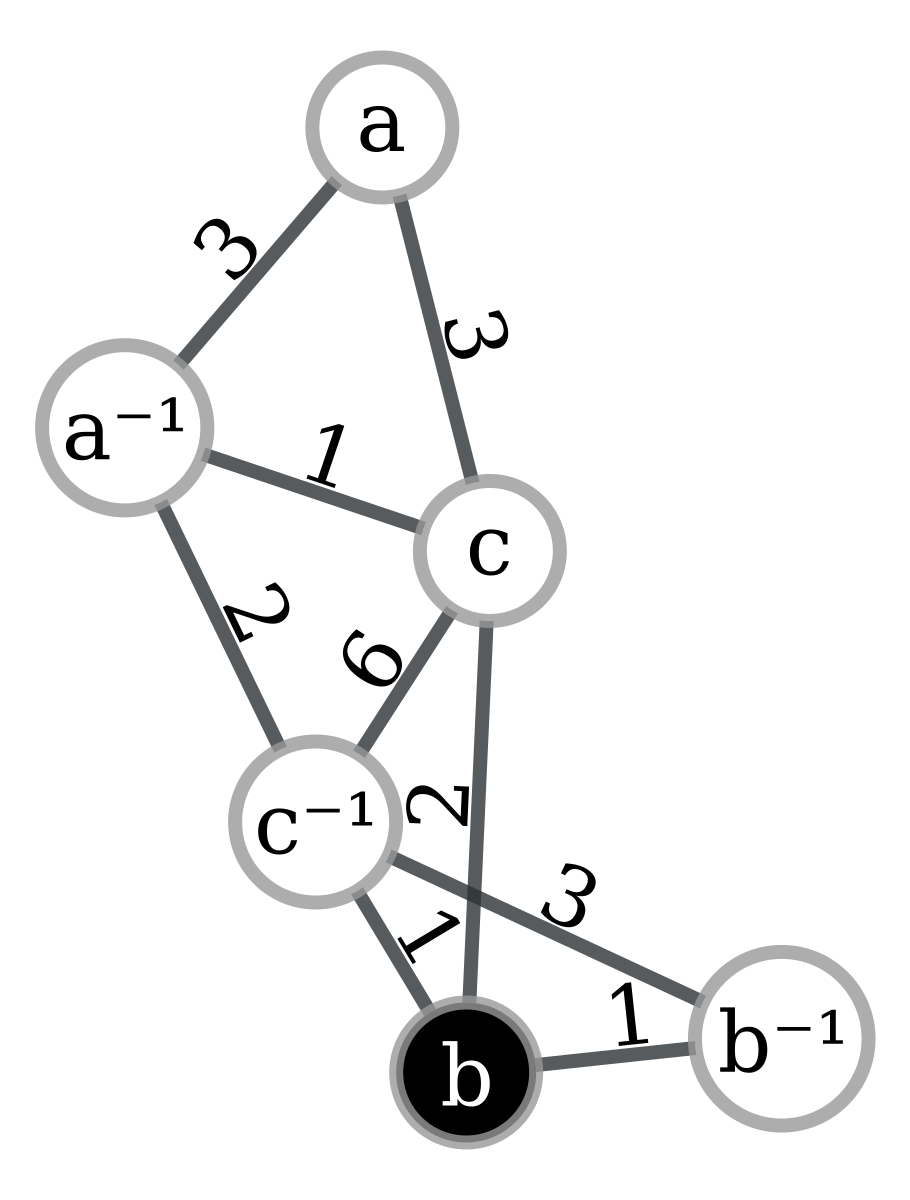

{b} {b⁻¹, c, a⁻¹, a, c⁻¹}


In [18]:
wh_graph = g
weight = wh_graph.edge_properties["weight"]
elem = wh_graph.vertex_properties["elem"]
v_text = wh_graph.new_vertex_property("string")
for v in wh_graph.vertices():
    v_text[v] = str(elem[v])
print(elem)
mc, part = min_cut(wh_graph, weight)
print(mc)
part1 = set()
part2 = set()
for v in g.vertices():
    (part1 if part[v] else part2).add(elem[v])
graph_draw(wh_graph, edge_text=weight, vertex_text=v_text, vertex_fill_color=part)
print(part1, part2)

In [4]:
def create_partitions(wh_graph : Graph) -> tuple[set[Elem], set[Elem]]:
    weight = wh_graph.edge_properties["weight"]
    elem = wh_graph.vertex_properties["elem"]
    mc, part = min_cut(wh_graph, weight)
    part1 = set()
    part2 = set()
    for v in wh_graph.vertices():
        (part1 if part[v] else part2).add(elem[v])
    return (part1, part2)